In [1]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from matplotlib.ticker import LogLocator

#plt.style.use('/Users/koichiro/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
#plt.style.use('/Users/koichiromacmini/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
plt.style.use('/Users/koichiromacstudio/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')

In [2]:
EbinsTES = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1])
EbinsMKID = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.1])

In [3]:
multiply = 1000

In [4]:
events_TESSHM10MeV = np.loadtxt('events_TESSHM10MeV.csv') * multiply
events_TESSHM100MeV = np.loadtxt('events_TESSHM100MeV.csv') * multiply
events_TESSHM1000MeV = np.loadtxt('events_TESSHM1000MeV.csv') * multiply

events_TESSHM_Disk10MeV_5percent = np.loadtxt('events_TESSHM+Disk10MeV_5percent.csv') * multiply
events_TESSHM_Disk10MeV_25percent = np.loadtxt('events_TESSHM+Disk10MeV_25percent.csv') * multiply
events_TESSHM_Disk1000MeV_5percent = np.loadtxt('events_TESSHM+Disk1000MeV_5percent.csv') * multiply
events_TESSHM_Disk1000MeV_25percent = np.loadtxt('events_TESSHM+Disk1000MeV_25percent.csv') * multiply

events_TESBound1000MeV = np.loadtxt('events_TESBound1000MeV.csv') * multiply

In [5]:
events_MKIDSHM10MeV = np.loadtxt('events_MKIDSHM10MeV.csv') * multiply
events_MKIDSHM100MeV = np.loadtxt('events_MKIDSHM100MeV.csv') * multiply
events_MKIDSHM1000MeV = np.loadtxt('events_MKIDSHM1000MeV.csv') * multiply

events_MKIDSHM_Disk10MeV_5percent = np.loadtxt('events_MKIDSHM+Disk10MeV_5percent.csv') * multiply
events_MKIDSHM_Disk10MeV_25percent = np.loadtxt('events_MKIDSHM+Disk10MeV_25percent.csv') * multiply
events_MKIDSHM_Disk1000MeV_5percent = np.loadtxt('events_MKIDSHM+Disk1000MeV_5percent.csv') * multiply
events_MKIDSHM_Disk1000MeV_25percent = np.loadtxt('events_MKIDSHM+Disk1000MeV_25percent.csv') * multiply

events_MKIDBound1000MeV = np.loadtxt('events_MKIDBound1000MeV.csv') * multiply

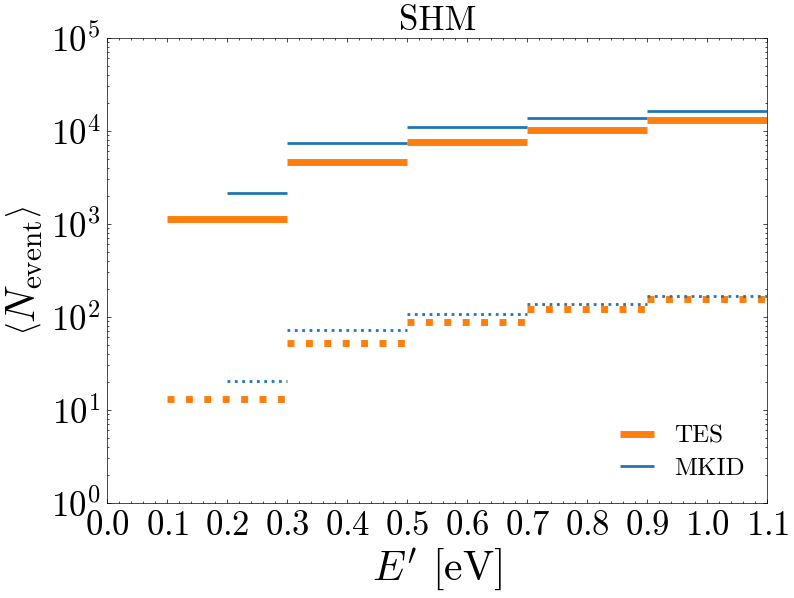

In [6]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

plt.hlines(events_TESSHM10MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, label = 'TES')
#plt.hlines(events_TESSHM100MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dashed')
plt.hlines(events_TESSHM1000MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dotted')

plt.hlines(events_MKIDSHM10MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, label = 'MKID')
#plt.hlines(events_MKIDSHM100MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dashed')
plt.hlines(events_MKIDSHM1000MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dotted')

#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.minorticks_on()
plt.xticks( np.arange(0, 1.2, 0.1))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize = 30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize = 30)
plt.title(r'SHM', fontsize = 25)
#plt.grid(True, which="both", ls="--")

plt.legend(loc = 'lower right', fontsize = 18, frameon = False)

plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM.pdf')

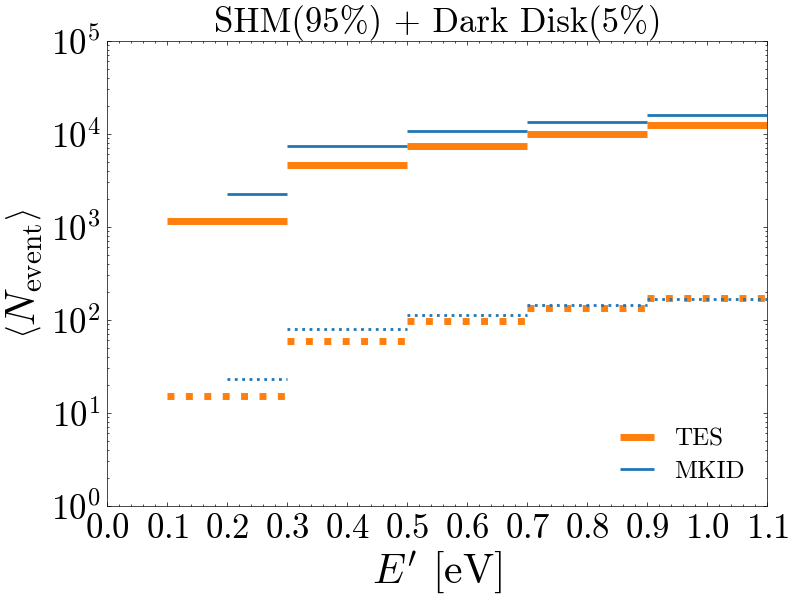

In [7]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

plt.hlines(events_TESSHM_Disk10MeV_5percent, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, label = 'TES')
#plt.hlines(events_TESSHM100MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dashed')
plt.hlines(events_TESSHM_Disk1000MeV_5percent, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dotted')

plt.hlines(events_MKIDSHM_Disk10MeV_5percent, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, label = 'MKID')
#plt.hlines(events_MKIDSHM100MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dashed')
plt.hlines(events_MKIDSHM_Disk1000MeV_5percent, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dotted')

#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.minorticks_on()
plt.xticks( np.arange(0, 1.2, 0.1))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize = 30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize = 30)
plt.title(r'SHM(95%) + Dark Disk(5%)', fontsize = 25)
#plt.grid(True, which="both", ls="--")

plt.legend(loc = 'lower right', fontsize = 18, frameon = False)

plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM+Disk_5percent.pdf')

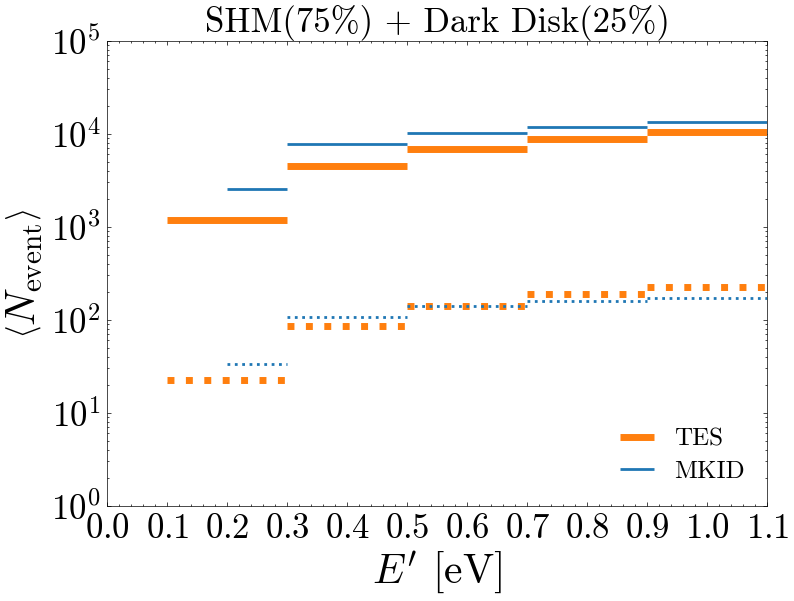

In [8]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

plt.hlines(events_TESSHM_Disk10MeV_25percent, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, label = 'TES')
#plt.hlines(events_TESSHM100MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dashed')
plt.hlines(events_TESSHM_Disk1000MeV_25percent, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dotted')

plt.hlines(events_MKIDSHM_Disk10MeV_25percent, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, label = 'MKID')
#plt.hlines(events_MKIDSHM100MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dashed')
plt.hlines(events_MKIDSHM_Disk1000MeV_25percent, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dotted')

#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.minorticks_on()
plt.xticks( np.arange(0, 1.2, 0.1))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize = 30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize = 30)
plt.title(r'SHM(75%) + Dark Disk(25%)', fontsize = 25)
#plt.grid(True, which="both", ls="--")

plt.legend(loc = 'lower right', fontsize = 18, frameon = False)

plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM+Disk_25percent.pdf')

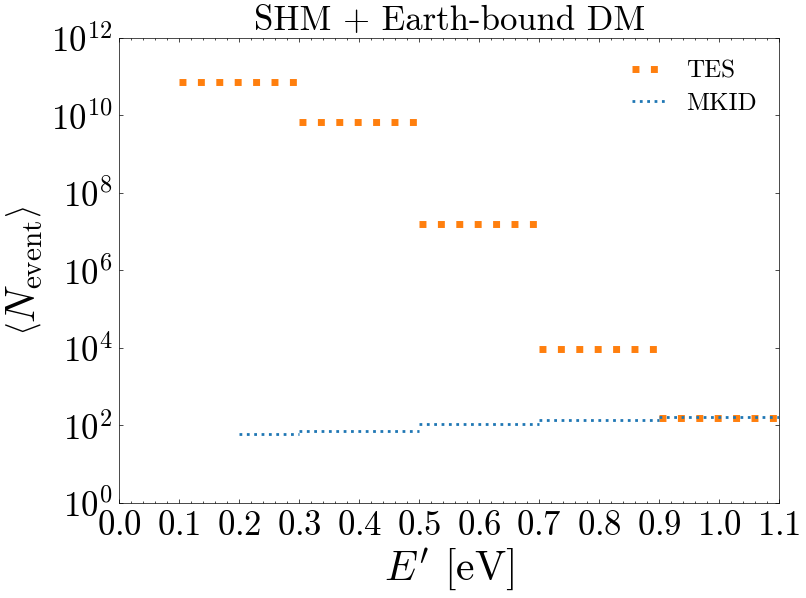

In [9]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

plt.hlines(events_TESBound1000MeV, EbinsTES[:-1], EbinsTES[1:], color = 'tab:orange', linewidth=5, linestyles='dotted', label = 'TES')

plt.hlines(events_MKIDBound1000MeV, EbinsMKID[:-1], EbinsMKID[1:], color = 'tab:blue', linewidth=2, linestyles='dotted', label = 'MKID')

#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.minorticks_on()
plt.xticks( np.arange(0, 1.2, 0.1))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize = 30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize = 30)
plt.title(r'SHM + Earth-bound DM', fontsize = 25)
#plt.grid(True, which="both", ls="--")

plt.legend(loc = 'upper right', fontsize = 18, frameon = False)

plt.yscale('log')
plt.ylim(1, 1e12)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_Bound.pdf')

# Errorbars

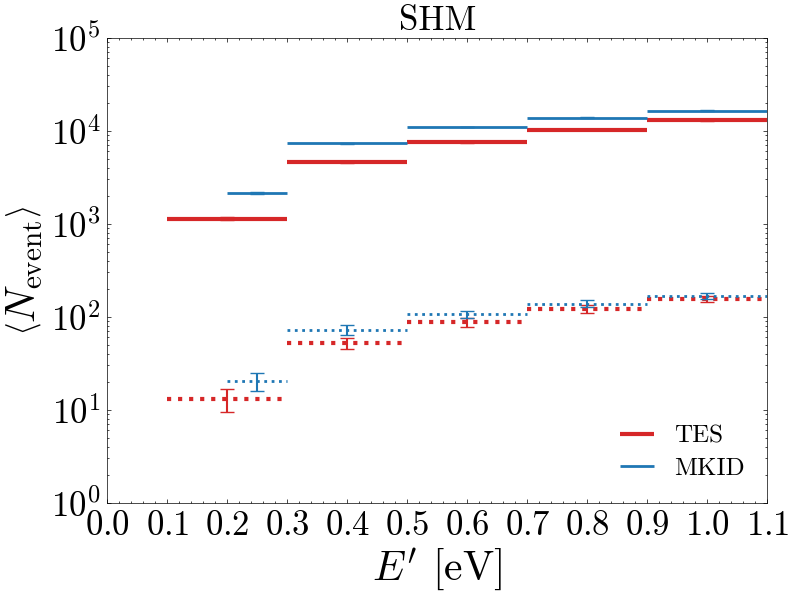

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# ビンの中点
midTES  = 0.5 * (EbinsTES[:-1]  + EbinsTES[1:])
midMKID = 0.5 * (EbinsMKID[:-1] + EbinsMKID[1:])

# --- TES ---
plt.hlines(events_TESSHM10MeV, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, label='TES')
plt.errorbar(midTES, events_TESSHM10MeV,
             yerr=np.sqrt(events_TESSHM10MeV),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

plt.hlines(events_TESSHM1000MeV, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, linestyles='dotted')
plt.errorbar(midTES, events_TESSHM1000MeV,
             yerr=np.sqrt(events_TESSHM1000MeV),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

# --- MKID ---
plt.hlines(events_MKIDSHM10MeV, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, label='MKID')
plt.errorbar(midMKID, events_MKIDSHM10MeV,
             yerr=np.sqrt(events_MKIDSHM10MeV),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.hlines(events_MKIDSHM1000MeV, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, linestyles='dotted')
plt.errorbar(midMKID, events_MKIDSHM1000MeV,
             yerr=np.sqrt(events_MKIDSHM1000MeV),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.minorticks_on()
plt.xticks(np.arange(0, 1.2, 0.1))
plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize=30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize=30)
plt.title(r'SHM', fontsize=25)
plt.legend(loc='lower right', fontsize=18, frameon=False)
plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM.pdf')

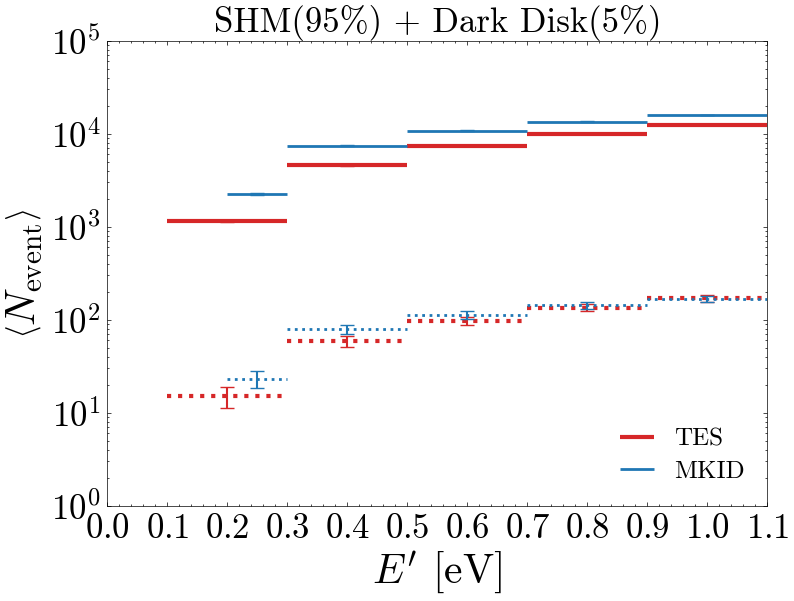

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# ビンの中点
midTES  = 0.5 * (EbinsTES[:-1]  + EbinsTES[1:])
midMKID = 0.5 * (EbinsMKID[:-1] + EbinsMKID[1:])

# --- TES ---
plt.hlines(events_TESSHM_Disk10MeV_5percent, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, label='TES')
plt.errorbar(midTES, events_TESSHM_Disk10MeV_5percent,
             yerr=np.sqrt(events_TESSHM_Disk10MeV_5percent),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

plt.hlines(events_TESSHM_Disk1000MeV_5percent, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, linestyles='dotted')
plt.errorbar(midTES, events_TESSHM_Disk1000MeV_5percent,
             yerr=np.sqrt(events_TESSHM_Disk1000MeV_5percent),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

# --- MKID ---
plt.hlines(events_MKIDSHM_Disk10MeV_5percent, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, label='MKID')
plt.errorbar(midMKID, events_MKIDSHM_Disk10MeV_5percent,
             yerr=np.sqrt(events_MKIDSHM_Disk10MeV_5percent),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.hlines(events_MKIDSHM_Disk1000MeV_5percent, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, linestyles='dotted')
plt.errorbar(midMKID, events_MKIDSHM_Disk1000MeV_5percent,
             yerr=np.sqrt(events_MKIDSHM_Disk1000MeV_5percent),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.minorticks_on()
plt.xticks(np.arange(0, 1.2, 0.1))
plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize=30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize=30)
plt.title(r'SHM(95%) + Dark Disk(5%)', fontsize=25)
plt.legend(loc='lower right', fontsize=18, frameon=False)
plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM+Disk_5percent.pdf')

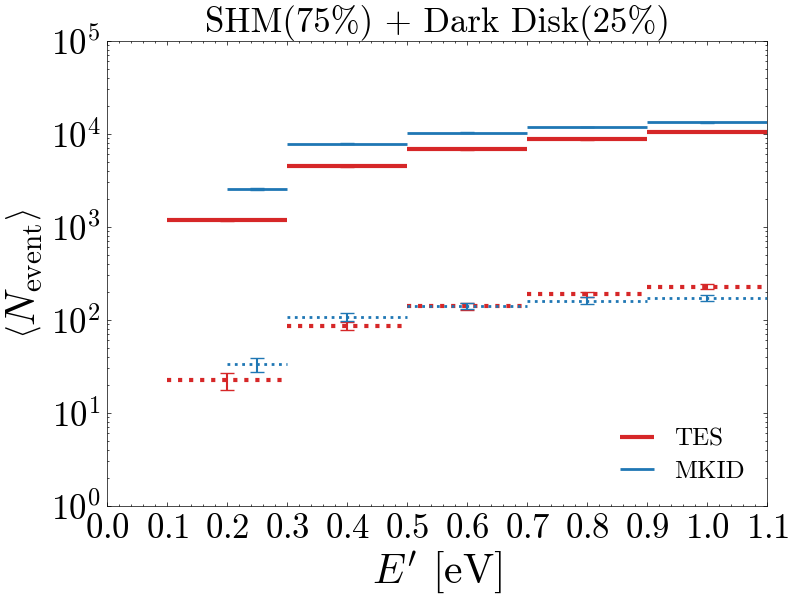

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# ビンの中点
midTES  = 0.5 * (EbinsTES[:-1]  + EbinsTES[1:])
midMKID = 0.5 * (EbinsMKID[:-1] + EbinsMKID[1:])

# --- TES ---
plt.hlines(events_TESSHM_Disk10MeV_25percent, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, label='TES')
plt.errorbar(midTES, events_TESSHM_Disk10MeV_25percent,
             yerr=np.sqrt(events_TESSHM_Disk10MeV_25percent),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

plt.hlines(events_TESSHM_Disk1000MeV_25percent, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, linestyles='dotted')
plt.errorbar(midTES, events_TESSHM_Disk1000MeV_25percent,
             yerr=np.sqrt(events_TESSHM_Disk1000MeV_25percent),
             fmt='none', ecolor='tab:red', capsize=5, linewidth=1.5)

# --- MKID ---
plt.hlines(events_MKIDSHM_Disk10MeV_25percent, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, label='MKID')
plt.errorbar(midMKID, events_MKIDSHM_Disk10MeV_25percent,
             yerr=np.sqrt(events_MKIDSHM_Disk10MeV_25percent),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.hlines(events_MKIDSHM_Disk1000MeV_25percent, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=2, linestyles='dotted')
plt.errorbar(midMKID, events_MKIDSHM_Disk1000MeV_25percent,
             yerr=np.sqrt(events_MKIDSHM_Disk1000MeV_25percent),
             fmt='none', ecolor='tab:blue', capsize=5, linewidth=1.5)

plt.minorticks_on()
plt.xticks(np.arange(0, 1.2, 0.1))
plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize=30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize=30)
plt.title(r'SHM(75%) + Dark Disk(25%)', fontsize=25)
plt.legend(loc='lower right', fontsize=18, frameon=False)
plt.yscale('log')
plt.ylim(1, 1e5)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_SHM+Disk_25percent.pdf')

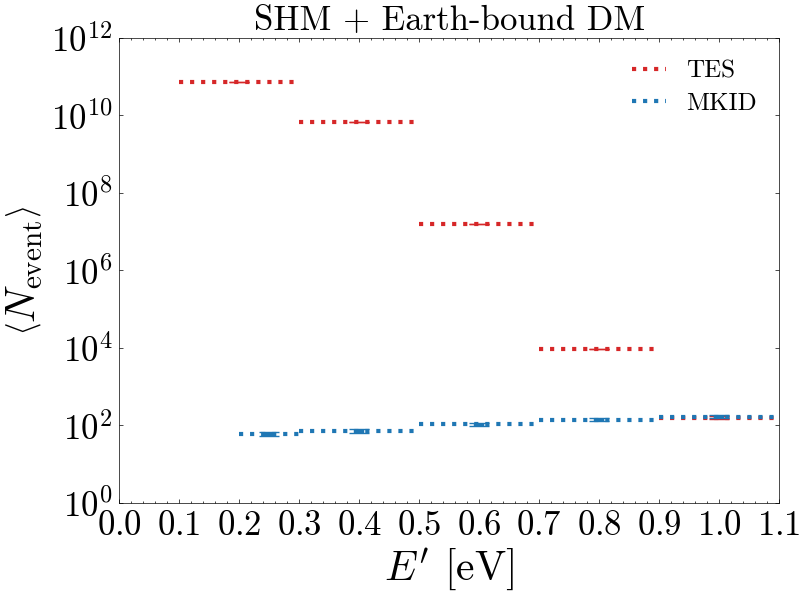

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# ビンの中点
midTES  = 0.5 * (EbinsTES[:-1]  + EbinsTES[1:])
midMKID = 0.5 * (EbinsMKID[:-1] + EbinsMKID[1:])

# --- TES ---
plt.hlines(events_TESBound1000MeV, EbinsTES[:-1], EbinsTES[1:],
           color='tab:red', linewidth=3, linestyles='dotted', label='TES')
plt.errorbar(midTES, events_TESBound1000MeV,
             yerr=np.sqrt(events_TESBound1000MeV),
             fmt='none', ecolor='tab:red', capsize=7, linewidth=7.5)

# --- MKID ---
plt.hlines(events_MKIDBound1000MeV, EbinsMKID[:-1], EbinsMKID[1:],
           color='tab:blue', linewidth=3, linestyles='dotted', label='MKID')
plt.errorbar(midMKID, events_MKIDBound1000MeV,
             yerr=np.sqrt(events_MKIDBound1000MeV),
             fmt='none', ecolor='tab:blue', capsize=7, linewidth=7.5)

plt.minorticks_on()
plt.xticks(np.arange(0, 1.2, 0.1))
plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$E^\prime$ [eV]", fontsize=30)
plt.ylabel(r"$\left<N_\text{event}\right>$", fontsize=30)
plt.title(r'SHM + Earth-bound DM', fontsize=25)
plt.legend(loc='upper right', fontsize=18, frameon=False)
plt.yscale('log')
plt.ylim(1, 1e12)
plt.xlim(0, 1.1)
plt.savefig('eventNumbers_Bound.pdf')